In [1]:
import sys
print(sys.executable)
# LÆG MÆRKE TIL DER ER 2 VERSIONER AF PYTHON 3.11.9. En version hvor Microsoft\WindowsApps er en del af PATH/addresse, 
# og en hvor det ikke er en del af PATH/addresse. Sørg for at vælge den der IKKE inderholder Microsoft/Windows
# (Gælder kun for min Bærbar Computer)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


$$r_{t,t+5}=\frac{close\_future - close\_now}{close\_now}$$

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Write the folder name only once
data_folder = "vol_1_ma_1_bb_0_rsi_0" # HUSK AT VÆLGE DET RIGTIGE MAPPE NAVN

pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

print(df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  future_return_5d
0   GILD     2024-04-16      0.558715         -0.004160
1   AAPL     2024-04-16      0.553102         -0.014642
2   ORCL     2024-04-16      0.535325         -0.045846
3    BSX     2024-04-16      0.539074          0.012772
4      C     2024-04-16      0.566512          0.099088


In [15]:
import os
import numpy as np
import pandas as pd
from scipy import stats

# ----------------------------
# Load predictions
# ----------------------------
data_folder = "vol_1_ma_1_bb_0_rsi_0"   # choose the right folder
pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

# ----------------------------
# Settings
# ----------------------------
n_groups = 5      # 10 = deciles
holding_days = 5   # R5 horizon

# ----------------------------
# Prepare variables
# ----------------------------
df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

df = df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].dropna().copy()

# If your file contains DAILY rolling predictions, but you want paper-style
# non-overlapping 5-day rebalances, uncomment these 2 lines:
# keep_dates = sorted(df["rebalance_date"].unique())[::holding_days]
# df = df[df["rebalance_date"].isin(keep_dates)].copy()

def assign_groups(probs: pd.Series, n_groups: int = 10) -> pd.Series:
    """
    Assign 1..n_groups within each rebalance date.
    rank(method='first') avoids qcut problems when probabilities tie.
    """
    if probs.notna().sum() < n_groups:
        return pd.Series(np.nan, index=probs.index)

    ranks = probs.rank(method="first")
    groups = pd.qcut(ranks, q=n_groups, labels=False) + 1
    return pd.Series(groups, index=probs.index)

# ----------------------------
# Sort into deciles within each rebalance date
# ----------------------------
df["decile"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(lambda x: assign_groups(x, n_groups=n_groups))
)

df = df.dropna(subset=["decile"]).copy()
df["decile"] = df["decile"].astype(int)

# ----------------------------
# Equal-weight portfolio return for each date x decile
# ----------------------------
period_ret = (
    df.groupby(["rebalance_date", "decile"])["future_return_5d"]
      .mean()
      .unstack("decile")
      .sort_index(axis=1)
)

# keep only dates where all deciles exist
period_ret = period_ret.dropna()

# ----------------------------
# Annualization helpers
# ----------------------------
ann_factor = 252 / holding_days

def annualized_return(x: pd.Series) -> float:
    return x.mean() * ann_factor

def annualized_sharpe(x: pd.Series) -> float:
    s = x.std(ddof=1)
    if pd.isna(s) or s == 0:
        return np.nan
    return (x.mean() / s) * np.sqrt(ann_factor)

# ----------------------------
# Build decile summary table
# ----------------------------
summary = pd.DataFrame({
    "Ret": period_ret.apply(annualized_return),
    "SR": period_ret.apply(annualized_sharpe),
})

# High-minus-Low
hl = period_ret[n_groups] - period_ret[1]
summary.loc["H-L", "Ret"] = annualized_return(hl)
summary.loc["H-L", "SR"]  = annualized_sharpe(hl)

# Optional significance stars for H-L mean return
tstat, pval = stats.ttest_1samp(hl.dropna(), popmean=0.0)
if pval < 0.001:
    stars = "***"
elif pval < 0.01:
    stars = "**"
elif pval < 0.05:
    stars = "*"
else:
    stars = ""

# Rename rows to match the paper style
summary = summary.rename(index={1: "Low", n_groups: "High"})

ordered_rows = ["Low"] + [i for i in range(2, n_groups)] + ["High", "H-L"]
summary = summary.loc[ordered_rows]

# Pretty printed version
table_out = summary.copy().reset_index()
table_out.columns = ["Decile", "Ret", "SR"]
table_out["Decile"] = table_out["Decile"].astype(str)
table_out.loc[table_out["Decile"] == "H-L", "Decile"] = f"H-L{stars}"

table_out["Ret"] = table_out["Ret"].map(lambda x: f"{x:.2f}")
table_out["SR"]  = table_out["SR"].map(lambda x: f"{x:.2f}")

print(table_out.to_string(index=False))

Decile  Ret   SR
   Low 0.23 1.67
     2 0.20 1.72
     3 0.28 1.87
     4 0.18 1.22
  High 0.28 1.95
   H-L 0.05 0.41


In [12]:
print(period_ret.mean())
print(hl.mean())

decile
1     0.006042
2     0.003062
3     0.002359
4     0.005733
5     0.006628
6     0.004327
7     0.003384
8     0.003941
9     0.001781
10    0.009086
dtype: float64
0.0030439154370972862


In [16]:
counts = df.groupby("rebalance_date")["ticker"].nunique()
print(counts.describe())
print(counts.head(20))

count    35.0
mean     93.0
std       0.0
min      93.0
25%      93.0
50%      93.0
75%      93.0
max      93.0
Name: ticker, dtype: float64
rebalance_date
2024-04-16    93
2024-04-23    93
2024-04-30    93
2024-05-07    93
2024-05-14    93
2024-05-21    93
2024-05-29    93
2024-06-05    93
2024-06-12    93
2024-06-20    93
2024-06-27    93
2024-07-05    93
2024-07-12    93
2024-07-19    93
2024-07-26    93
2024-08-02    93
2024-08-09    93
2024-08-16    93
2024-08-23    93
2024-08-30    93
Name: ticker, dtype: int64


In [17]:
decile_counts = df.groupby(["rebalance_date", "decile"])["ticker"].nunique().unstack()
print(decile_counts.head())
print(decile_counts.describe())

decile           1   2   3   4   5
rebalance_date                    
2024-04-16      19  18  19  18  19
2024-04-23      19  18  19  18  19
2024-04-30      19  18  19  18  19
2024-05-07      19  18  19  18  19
2024-05-14      19  18  19  18  19
decile     1     2     3     4     5
count   35.0  35.0  35.0  35.0  35.0
mean    19.0  18.0  19.0  18.0  19.0
std      0.0   0.0   0.0   0.0   0.0
min     19.0  18.0  19.0  18.0  19.0
25%     19.0  18.0  19.0  18.0  19.0
50%     19.0  18.0  19.0  18.0  19.0
75%     19.0  18.0  19.0  18.0  19.0
max     19.0  18.0  19.0  18.0  19.0


In [3]:
n_groups = 10   # use 10 in final analysis

In [4]:
def assign_groups(prob_series):
    if len(prob_series) < n_groups:
        return pd.Series([np.nan] * len(prob_series), index=prob_series.index)

    ranked = prob_series.rank(method="first")

    return pd.qcut(
        ranked,
        q=n_groups,
        labels=False
    ) + 1

df["group"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(assign_groups)
)

df = df.dropna(subset=["group"]).copy()
df["group"] = df["group"].astype(int)

print(df[["ticker", "rebalance_date", "pred_prob_up", "group", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  group  future_return_5d
0   GILD     2024-04-16      0.558715      6         -0.004160
1   AAPL     2024-04-16      0.553102      5         -0.014642
2   ORCL     2024-04-16      0.535325      1         -0.045846
3    BSX     2024-04-16      0.539074      1          0.012772
4      C     2024-04-16      0.566512      9          0.099088


In [5]:
portfolio_returns = (
    df.groupby(["rebalance_date", "group"])["future_return_5d"]
      .mean()
      .reset_index()
)

print(portfolio_returns.head())

  rebalance_date  group  future_return_5d
0     2024-04-16      1         -0.008999
1     2024-04-16      2          0.012654
2     2024-04-16      3          0.000069
3     2024-04-16      4          0.014750
4     2024-04-16      5         -0.002047


In [6]:
portfolio_wide = portfolio_returns.pivot(
    index="rebalance_date",
    columns="group",
    values="future_return_5d"
)

portfolio_wide.columns = [f"G{int(c)}" for c in portfolio_wide.columns]

low_col = "G1"
high_col = f"G{n_groups}"

portfolio_wide["H-L"] = portfolio_wide[high_col] - portfolio_wide[low_col]

print(portfolio_wide.head())

                      G1        G2        G3        G4        G5        G6  \
rebalance_date                                                               
2024-04-16     -0.008999  0.012654  0.000069  0.014750 -0.002047  0.019087   
2024-04-23     -0.010135 -0.013838 -0.021437 -0.005823 -0.013974 -0.002285   
2024-04-30      0.038622  0.026248  0.015060  0.024469  0.026264  0.041700   
2024-05-07      0.011226  0.010410 -0.005919  0.016035  0.013527  0.009498   
2024-05-14      0.026413  0.015260  0.025511  0.008039 -0.007624  0.006533   

                      G7        G8        G9       G10       H-L  
rebalance_date                                                    
2024-04-16      0.040393  0.008674  0.031796  0.012478  0.021476  
2024-04-23      0.003233 -0.017716 -0.005041  0.023607  0.033742  
2024-04-30      0.032048  0.027446  0.013452  0.034031 -0.004591  
2024-05-07     -0.016934  0.039728  0.018282  0.012584  0.001358  
2024-05-14      0.017035  0.018241  0.013168  0.015

In [7]:
periods_per_year = 252 / 5

def annualized_return(r):
    return r.mean() * periods_per_year

def annualized_sharpe(r):
    std = r.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return (r.mean() / std) * np.sqrt(periods_per_year)

def p_value_mean_zero(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    t_stat, p_val = stats.ttest_1samp(r, popmean=0.0, nan_policy="omit")
    return p_val

def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary_rows = []

for g in range(1, n_groups + 1):
    col = f"G{g}"
    r = portfolio_wide[col].dropna()

    if g == 1:
        label = "Low"
    elif g == n_groups:
        label = "High"
    else:
        label = str(g)

    p = p_value_mean_zero(r)

    summary_rows.append({
        "Group": label,
        "Ret": annualized_return(r),
        "SR": annualized_sharpe(r),
        "p_value": p,
        "stars": stars_from_p(p)
    })

# Add H-L
r_hl = portfolio_wide["H-L"].dropna()
p_hl = p_value_mean_zero(r_hl)

summary_rows.append({
    "Group": "H-L",
    "Ret": annualized_return(r_hl),
    "SR": annualized_sharpe(r_hl),
    "p_value": p_hl,
    "stars": stars_from_p(p_hl)
})

summary_table = pd.DataFrame(summary_rows)

summary_table["Ret"] = summary_table["Ret"].round(2)
summary_table["SR_display"] = summary_table["SR"].map(lambda x: f"{x:.2f}") + summary_table["stars"]

print(summary_table[["Group", "Ret", "SR_display", "p_value"]].to_string(index=False))

Group  Ret SR_display  p_value
  Low 0.30       1.80 0.142128
    2 0.15       1.17 0.334647
    3 0.12       0.87 0.473030
    4 0.29       2.35 0.058935
    5 0.33       2.09 0.090886
    6 0.22       1.40 0.251162
    7 0.17       1.22 0.314996
    8 0.20       0.89 0.460949
    9 0.09       0.53 0.663038
 High 0.46      2.70* 0.030815
  H-L 0.15       1.12 0.356489


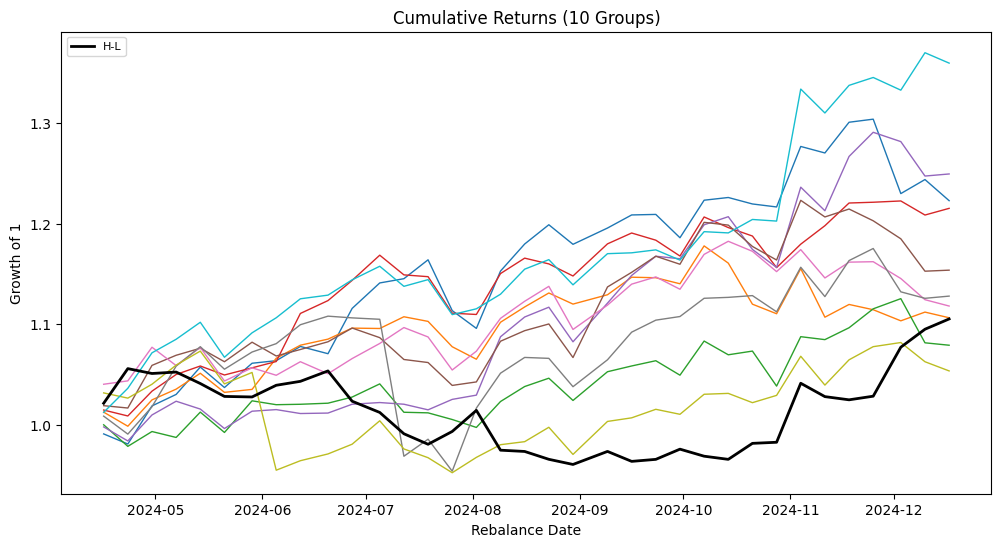

In [8]:
cum_df = (1 + portfolio_wide.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(cum_df.index, cum_df[f"G{g}"], linewidth=1)

plt.plot(cum_df.index, cum_df["H-L"], linewidth=2, color="black", label="H-L")

plt.title(f"Cumulative Returns ({n_groups} Groups)")
plt.ylabel("Growth of 1")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()

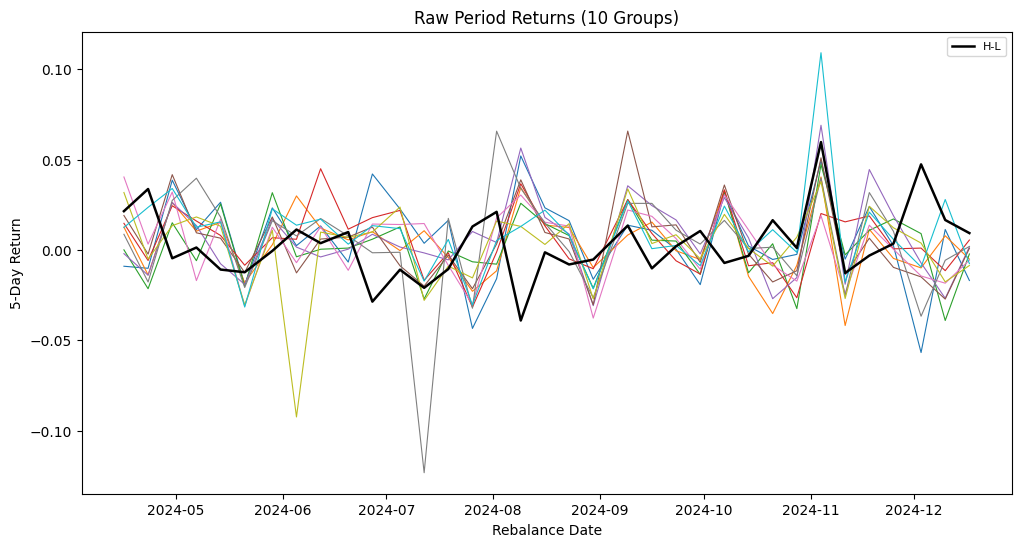

In [9]:
plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(portfolio_wide.index, portfolio_wide[f"G{g}"], linewidth=0.8)

plt.plot(portfolio_wide.index, portfolio_wide["H-L"], linewidth=1.8, color="black", label="H-L")

plt.title(f"Raw Period Returns ({n_groups} Groups)")
plt.ylabel("5-Day Return")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()